В обвчном hog считаем градиенты (gx, gy). Далее считаем модель и угол и делим картинку на ячейке и в каждой ячейке строим гистограмму направлений после чего склеиваем все гистограммы в дин вектор НО
если картинку повернуть ее углы градиентов сдвигаются и соотвественн гистограммы меняются поэтому наш дескриптор неинвариантен к повороту

Решение:

Построить глобальную гистограмму направлений (сумма гистограмм всех ячеек) и находим ведущее направление (bias с макс значением ) далее циклически сдвигаем все локальные гистограммы так чтобы bias  стал нулевым  то есть поворачиваем систему координат градиентов - не картинку. После этого склеиваются гистаграмы в финальный дескриптор. Тогда при повороте изображения все градиенты просто смещаются на одинаковый угол но они нормазируются к ведущему напрвелнию - т е дискриптор становится инвариантен к повороту

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
#реализация базового hog

In [7]:

def compute_hog_cells(gray, cell_size=(8, 8), nbins=9):
    """
    Строит HOG-дескриптор на уровне ячеек (без блоков) и возвращает массив формы (n_cells_y, n_cells_x, nbins)
    """
    # градиенты
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=1)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=1)

    mag, ang = cv2.cartToPolar(gx, gy, angleInDegrees=True)
    # приводим к диапазону [0, 180) — неориентированный градиент
    ang = np.mod(ang, 180.0)

    h, w = gray.shape
    cell_h, cell_w = cell_size

    n_cells_y = h // cell_h
    n_cells_x = w // cell_w

    hog = np.zeros((n_cells_y, n_cells_x, nbins), dtype=np.float32)

    # границы биннов: [0, 20, 40, ..., 180] если nbins=9
    bins = np.linspace(0, 180, nbins + 1)

    for i in range(n_cells_y):
        for j in range(n_cells_x):
            m = mag[i * cell_h:(i + 1) * cell_h,
                    j * cell_w:(j + 1) * cell_w]
            a = ang[i * cell_h:(i + 1) * cell_h,
                    j * cell_w:(j + 1) * cell_w]

            hist, _ = np.histogram(a, bins=bins, weights=m)
            hog[i, j, :] = hist

    return hog#,(n_cells_y, n_cells_x, nbins)

In [8]:
#Поворотно-инвариантный HOG - сдвигаем гистограммы так, чтобы главный пик стал в нулевом бине

def make_rot_invariant(hog_cells):
    """
    Принимает HOG на уровне ячеек: (n_cells_y, n_cells_x, nbins) и возвращает такой же массив но с циклическим сдвигом бинов,
    чтобы глобальное максимальное направление стало нулевым бином
    """
    # глобальная гистограмма (по всей картинке)
    global_hist = hog_cells.sum(axis=(0, 1))  # (nbins,)

    # индекс бина с максимальным значением
    main_bin = int(np.argmax(global_hist))

    # свдиваем все гистограммы по оси бинов
    hog_rot = np.roll(hog_cells, shift=-main_bin, axis=2)
    return hog_rot, main_bin

In [9]:
def hog_to_descriptor(hog_cells, norm="l2", eps=1e-6):
    """
    Распрямляет HOG (n_cells_y, n_cells_x, nbins) в вектор и нормализует
    norm: "l2" или "l1"
    """
    desc = hog_cells.ravel().astype(np.float32)

    if norm is None:
        return desc

    if norm.lower() == "l2":
        n = np.linalg.norm(desc)
        if n > 0:
            desc = desc / (n + eps)
    elif norm.lower() == "l1":
        n = np.sum(np.abs(desc))
        if n > 0:
            desc = desc / (n + eps)

    return desc

In [10]:
def l1_l2_distance(d1, d2):
    """
    Считает L1 и L2 расстояние между двумя векторами
    """
    diff = d1 - d2
    l1 = np.sum(np.abs(diff))
    l2 = np.sqrt(np.sum(diff ** 2))
    return float(l1), float(l2)


# вспомогательная функция для поворота изображения

def rotate_image(image, angle_deg):
    """
    Поворачивает изображение на angle_deg (по часовой стрелке, если angle > 0)
    """
    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h),
                             flags=cv2.INTER_LINEAR,
                             borderMode=cv2.BORDER_CONSTANT,
                             borderValue=0)
    return rotated

def demo_rotation_invariance(
    image_path,
    angles=(30, 60, 90),
    cell_size=(8, 8),
    nbins=9,
):
    """
    Визуализация поворотно-инвариантного hog
    image_path — путь к исходному изображению
    angles — список углов поворота

    Для каждой повернутой картинки печатаем:
      - L1, L2 между обычными hog
      - L1, L2 между поворотно-инвариантными hog
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Не удалось загрузить изображение: {image_path}")

    # приводим к фиксированному размеру
    img = cv2.resize(img, (128, 128))

    # HOG для исходного изображения
    hog_base = compute_hog_cells(img, cell_size=cell_size, nbins=nbins)
    hog_base_desc = hog_to_descriptor(hog_base, norm="l2")

    hog_base_rot, main_bin_base = make_rot_invariant(hog_base)
    hog_base_rot_desc = hog_to_descriptor(hog_base_rot, norm="l2")

    print(f"Исходное изображение: {image_path}")
    print(f"Размер: {img.shape}")
    print(f"Главный bin для исходного изображения: {main_bin_base}")
    print("-" * 60)

    for angle in angles:
        img_rot = rotate_image(img, angle)

        # обычный hog
        hog_rot = compute_hog_cells(img_rot, cell_size=cell_size, nbins=nbins)
        hog_rot_desc = hog_to_descriptor(hog_rot, norm="l2")

        # поворотно-инвариантный hog
        hog_rot_inv, main_bin_rot = make_rot_invariant(hog_rot)
        hog_rot_inv_desc = hog_to_descriptor(hog_rot_inv, norm="l2")

        # L1 и L2 без инвариантности
        l1_plain, l2_plain = l1_l2_distance(hog_base_desc, hog_rot_desc)

        # L1 и L2 с инвариантностью
        l1_inv, l2_inv = l1_l2_distance(hog_base_rot_desc, hog_rot_inv_desc)

        print(f"Угол поворота: {angle}°")
        print(f" Главный bin для повернутого изображения: {main_bin_rot}")
        print(f"Без инвариантности:  L1 = {l1_plain:.4f},  L2 = {l2_plain:.4f}")
        print(f" С инвариантностью:   L1 = {l1_inv:.4f},   L2 = {l2_inv:.4f}")
        print("-" * 60)

        fig, ax = plt.subplots(1, 2, figsize=(6, 3))
        ax[0].imshow(img, cmap="gray")
        ax[0].set_title("Исходное")
        ax[0].axis("off")
        ax[1].imshow(img_rot, cmap="gray")
        ax[1].set_title(f"Поворот {angle}°")
        ax[1].axis("off")
        plt.show()


Исходное изображение: /content/blackArrowIcon.jpg
Размер: (128, 128)
Главный bin для исходного изображения: 4
------------------------------------------------------------
Угол поворота: 30°
 Главный bin для повернутого изображения: 2
Без инвариантности:  L1 = 20.8355,  L2 = 1.3308
 С инвариантностью:   L1 = 19.7478,   L2 = 1.2698
------------------------------------------------------------


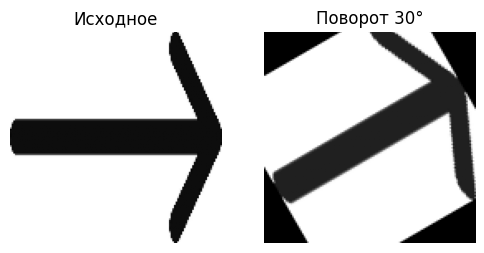

Угол поворота: 60°
 Главный bin для повернутого изображения: 1
Без инвариантности:  L1 = 19.7666,  L2 = 1.3410
 С инвариантностью:   L1 = 20.3204,   L2 = 1.3245
------------------------------------------------------------


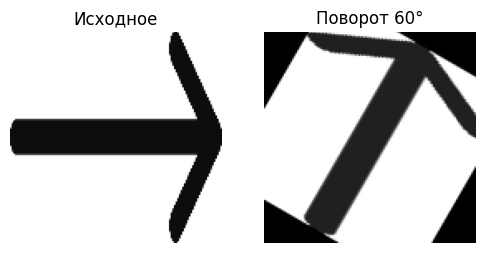

Угол поворота: 90°
 Главный bin для повернутого изображения: 0
Без инвариантности:  L1 = 19.4456,  L2 = 1.4016
 С инвариантностью:   L1 = 17.8582,   L2 = 1.3247
------------------------------------------------------------


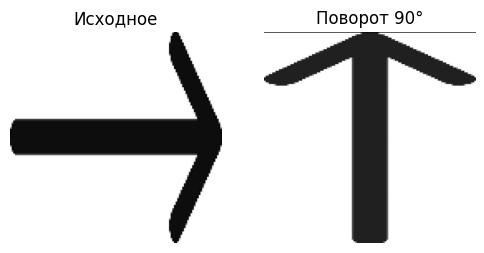

In [12]:
demo_rotation_invariance("/content/blackArrowIcon.jpg", angles=(30, 60, 90))

Исходное изображение: /content/main.jpg
Размер: (128, 128)
Главный bin для исходного изображения: 4
------------------------------------------------------------
Угол поворота: 15°
 Главный bin для повернутого изображения: 7
Без инвариантности:  L1 = 28.0676,  L2 = 1.1322
 С инвариантностью:   L1 = 32.4524,   L2 = 1.2352
------------------------------------------------------------


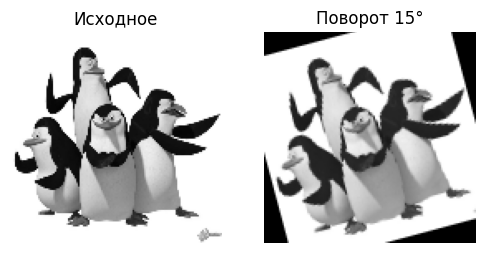

Угол поворота: 30°
 Главный bin для повернутого изображения: 7
Без инвариантности:  L1 = 31.0619,  L2 = 1.2147
 С инвариантностью:   L1 = 32.6795,   L2 = 1.2391
------------------------------------------------------------


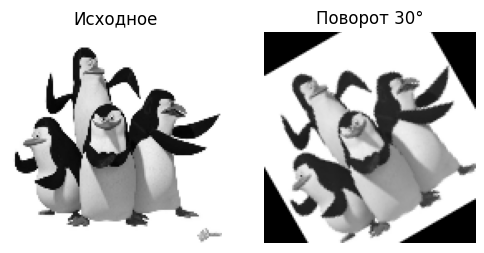

Угол поворота: 45°
 Главный bin для повернутого изображения: 6
Без инвариантности:  L1 = 29.1115,  L2 = 1.2353
 С инвариантностью:   L1 = 29.9916,   L2 = 1.2602
------------------------------------------------------------


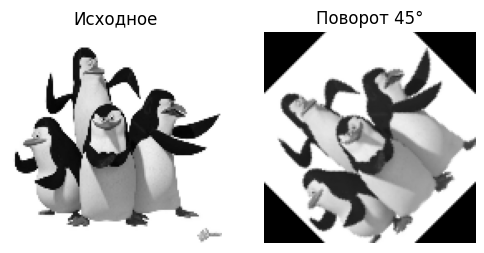

Угол поворота: 120°
 Главный bin для повернутого изображения: 2
Без инвариантности:  L1 = 33.6133,  L2 = 1.2667
 С инвариантностью:   L1 = 32.1140,   L2 = 1.2161
------------------------------------------------------------


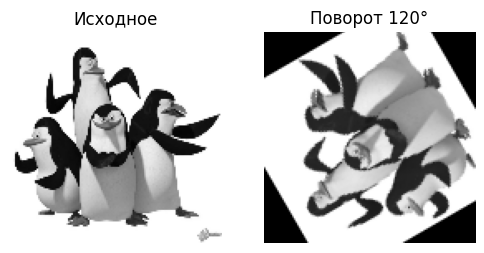

In [13]:
demo_rotation_invariance("/content/main.jpg", angles=(15, 30, 45, 120))

Исходное изображение: /content/2025-11-26 10.20.21.jpg
Размер: (128, 128)
Главный bin для исходного изображения: 4
------------------------------------------------------------
Угол поворота: 30°
 Главный bin для повернутого изображения: 2
Без инвариантности:  L1 = 29.7281,  L2 = 1.0700
 С инвариантностью:   L1 = 27.2354,   L2 = 0.9870
------------------------------------------------------------


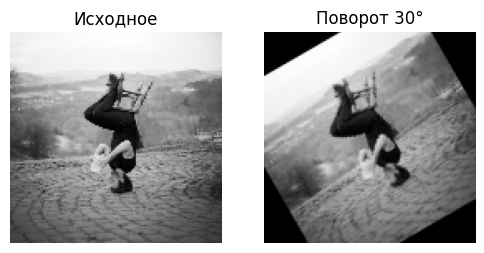

Угол поворота: 90°
 Главный bin для повернутого изображения: 0
Без инвариантности:  L1 = 33.3067,  L2 = 1.0519
 С инвариантностью:   L1 = 31.6017,   L2 = 1.0539
------------------------------------------------------------


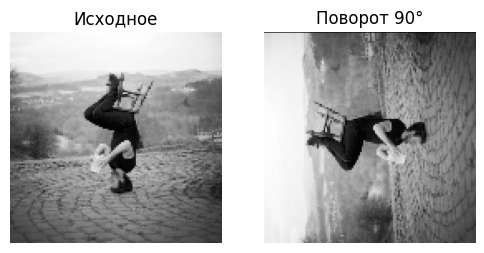

Угол поворота: 180°
 Главный bin для повернутого изображения: 4
Без инвариантности:  L1 = 31.7901,  L2 = 1.0140
 С инвариантностью:   L1 = 31.7901,   L2 = 1.0140
------------------------------------------------------------


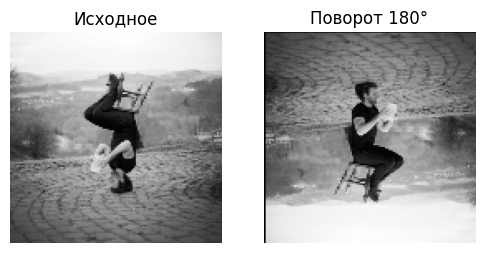

In [14]:
demo_rotation_invariance("/content/2025-11-26 10.20.21.jpg", angles=(30, 90, 180))